# RegimeLab Phase 1: SPY Market Regime Analysis

This notebook is the Phase 1 foundation for the **RegimeLab** project. It studies SPY market regimes using K-Means clustering on three rolling features: realised volatility, momentum, and drawdown.

The goal is to classify historical market environments — **Calm**, **Choppy**, and **Stressed** — to prepare for event-window analysis (CPI or FOMC releases) in later phases.

---

**Disclaimer:** This is purely an analytical exercise. It makes no claims about profitable trading or future prediction. All rolling features use only past data (`min_periods` enforced). However, K-Means is fitted on the full historical dataset, which introduces a form of lookahead bias if the resulting labels are used naively in backtesting. This is clearly noted where relevant.


In [1]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\vissh\code\regimelab\.venv\Scripts\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


## 0. Imports and Setup


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 7)
print("Imports OK")


Imports OK


## 1. Data Download and Caching

We download SPY daily OHLCV data from Yahoo Finance via `yfinance`, starting from 2005-01-01. The raw data is cached locally as `data/spy_daily.csv` to avoid redundant API calls on subsequent runs.

**Assumption:** We use the adjusted `Close` price (which accounts for splits and dividends) as the basis for all feature calculations.


In [3]:
DATA_DIR = '../data'
CACHE_FILE = os.path.join(DATA_DIR, 'spy_daily.csv')
os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(CACHE_FILE):
    print(f"Loading data from cache: {CACHE_FILE}")
    df = pd.read_csv(CACHE_FILE, index_col='Date', parse_dates=True)
else:
    print("Downloading SPY data from yfinance...")
    spy = yf.Ticker("SPY")
    df = spy.history(start="2005-01-01")
    # Remove timezone info for simplicity
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df.to_csv(CACHE_FILE)
    print(f"Data cached to: {CACHE_FILE}")

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()


Loading data from cache: ../data\spy_daily.csv
Data shape: (5371, 8)
Date range: 2005-01-03 to 2026-05-08


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2005-01-03,82.236138,82.371442,81.113140,81.383743,55748000,0.0,0.0,0.0
2005-01-04,81.491978,81.546100,80.125437,80.389275,69167600,0.0,0.0,0.0
2005-01-05,80.328381,80.673400,79.827767,79.834534,65667300,0.0,0.0,0.0
2005-01-06,80.125405,80.605724,80.003634,80.240410,47814700,0.0,0.0,0.0
2005-01-07,80.483983,80.659876,79.915714,80.125435,55847700,0.0,0.0,0.0


## 2. Data Cleaning

We remove duplicate date entries (keeping the first occurrence) and drop any rows where the `Close` price is NaN.


In [4]:
# Remove duplicate index entries
n_dupes = df.index.duplicated().sum()
df = df[~df.index.duplicated(keep='first')]
print(f"Duplicate dates removed: {n_dupes}")

# Drop rows with NaN in Close
n_nan = df['Close'].isna().sum()
df = df.dropna(subset=['Close'])
print(f"NaN rows removed: {n_nan}")

print(f"Clean data shape: {df.shape}")


Duplicate dates removed: 0
NaN rows removed: 0
Clean data shape: (5371, 8)


## 3. Feature Engineering

We compute four features, all based on the adjusted `Close` price. Each feature uses only current and past data (no lookahead bias in the feature construction itself).

| Feature | Formula | Window |
|---|---|---|
| `Log_Return` | $\ln(P_t / P_{t-1})$ | 1-day |
| `Vol_20d` | $\sigma_{20} \times \sqrt{252}$ (annualised) | 20-day rolling |
| `Mom_20d` | $\sum_{i=0}^{19} r_{t-i}$ (cumulative log return) | 20-day rolling |
| `Drawdown_60d` | $(P_t - \max_{60}) / \max_{60}$ | 60-day rolling max |

**Note on `min_periods`:** All rolling calculations use `min_periods` equal to the window size. Rows with insufficient history are returned as NaN and dropped later.

**Lookahead Bias Warning:** The features themselves are constructed without lookahead. However, K-Means clustering in Section 5 is fitted on the entire dataset, meaning the cluster centroids reflect the full history. This is acceptable for exploratory regime labelling but must not be used directly in a walk-forward backtest.


In [5]:
# 1. Daily Log Returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# 2. 20-day Annualised Realised Volatility
df['Vol_20d'] = (
    df['Log_Return']
    .rolling(window=20, min_periods=20)
    .std() * np.sqrt(252)
)

# 3. 20-day Momentum (cumulative log return over 20 days)
df['Mom_20d'] = (
    df['Log_Return']
    .rolling(window=20, min_periods=20)
    .sum()
)

# 4. 60-day Rolling Drawdown
roll_max_60d = df['Close'].rolling(window=60, min_periods=60).max()
df['Drawdown_60d'] = (df['Close'] - roll_max_60d) / roll_max_60d

df[['Close', 'Log_Return', 'Vol_20d', 'Mom_20d', 'Drawdown_60d']].tail(10)


,Close,Log_Return,Vol_20d,Mom_20d,Drawdown_60d
Date,,,,,
2026-04-27,715.169983,0.001721,0.142623,0.120329,0.000000
2026-04-28,711.690002,-0.004878,0.144050,0.118801,-0.004866
2026-04-29,711.580017,-0.000155,0.117688,0.089993,-0.005020
2026-04-30,718.659973,0.009900,0.118800,0.092387,0.000000
2026-05-01,720.650024,0.002765,0.118209,0.094252,0.000000
2026-05-04,718.010010,-0.003670,0.121896,0.085866,-0.003663
2026-05-05,723.770020,0.007990,0.121677,0.093416,0.000000
2026-05-06,733.830017,0.013804,0.101308,0.082070,0.000000
2026-05-07,731.580017,-0.003071,0.104203,0.073246,-0.003066


## 4. Assemble Feature DataFrame and Standardise

We select the three clustering features, drop the NaN warmup rows (the first ~60 rows), and standardise with `StandardScaler` so that K-Means treats each feature equally regardless of scale.


In [6]:
FEATURE_COLS = ['Vol_20d', 'Mom_20d', 'Drawdown_60d']

# Drop NaN warmup rows
features_df = df[FEATURE_COLS].dropna().copy()
print(f"Features shape after dropping NaN warmup: {features_df.shape}")

# Standardise features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

# Quick sanity check
print("Feature means (should be ~0 after scaling):", scaled_features.mean(axis=0).round(4))
print("Feature stds  (should be ~1 after scaling):", scaled_features.std(axis=0).round(4))


Features shape after dropping NaN warmup: (5312, 3)
Feature means (should be ~0 after scaling): [-0. -0.  0.]
Feature stds  (should be ~1 after scaling): [1. 1. 1.]


## 5. K-Means Clustering: Silhouette Analysis (k = 2, 3, 4, 5)

We run K-Means for k = 2, 3, 4, 5 and compute the **silhouette score** for each. The silhouette score measures how similar each point is to its own cluster compared to other clusters; higher is better (range: -1 to 1).


    k      Silhouette Score
------------------------------
    2                0.6125
    3                0.5386
    4                0.3923
    5                0.4183


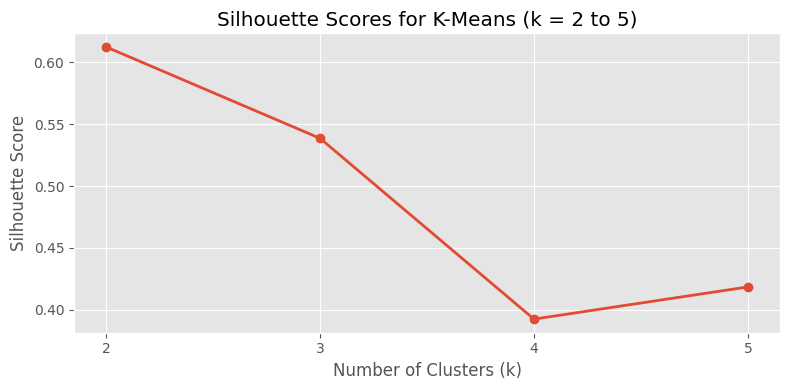

In [7]:
k_values = [2, 3, 4, 5]
silhouette_scores = []

print(f"{'k':>5}  {'Silhouette Score':>20}")
print("-" * 30)

for k in k_values:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = km_temp.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels_temp)
    silhouette_scores.append(score)
    print(f"{k:>5}  {score:>20.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', linewidth=2)
plt.title('Silhouette Scores for K-Means (k = 2 to 5)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.tight_layout()
plt.show()


## 6. Fit Final K-Means Model (k = 3)

We choose k = 3 as it maps naturally to three economically interpretable regimes: **Calm**, **Choppy**, and **Stressed**. We use `random_state=42` for reproducibility and `n_init=10` to run 10 independent initialisations and select the best result.


In [8]:
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
features_df = features_df.copy()
features_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Align clusters back to the main dataframe
df['Cluster'] = np.nan
df.loc[features_df.index, 'Cluster'] = features_df['Cluster']

print(f"K-Means fitted with k={K_FINAL}")
print("Cluster value counts:")
print(features_df['Cluster'].value_counts().sort_index())


K-Means fitted with k=3
Cluster value counts:
Cluster
0    4080
1    1138
2      94
Name: count, dtype: int64


## 7. Cluster Centroids and Economic Labels

We inverse-transform the cluster centroids back to their original units to interpret them. We then assign labels based on the **annualised volatility** of each centroid:

- **Lowest volatility** cluster → **Calm** (low vol, positive momentum, near-zero drawdown)
- **Middle volatility** cluster → **Choppy** (moderate vol, mixed momentum, moderate drawdown)
- **Highest volatility** cluster → **Stressed** (high vol, negative momentum, deep drawdown)

This labelling is deterministic and based on centroid ordering, not manual inspection.


In [9]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=FEATURE_COLS,
    index=pd.RangeIndex(K_FINAL, name='Cluster')
)

print("Centroids in original units:")
print(centroids_df.round(4).to_string())

# Assign labels by sorting clusters on Vol_20d (ascending)
sorted_by_vol = centroids_df['Vol_20d'].sort_values().index.tolist()
label_map = {
    sorted_by_vol[0]: 'Calm',
    sorted_by_vol[1]: 'Choppy',
    sorted_by_vol[2]: 'Stressed'
}

df['Regime'] = df['Cluster'].map(label_map)

print()
print("Regime label assignment:")
for cluster_id, regime in label_map.items():
    vol = centroids_df.loc[cluster_id, 'Vol_20d']
    mom = centroids_df.loc[cluster_id, 'Mom_20d']
    dd  = centroids_df.loc[cluster_id, 'Drawdown_60d']
    print(f"  Cluster {cluster_id} -> {regime:8s}  |  Vol={vol:.4f}  Mom={mom:.4f}  DD={dd:.4f}")


Centroids in original units:
         Vol_20d  Mom_20d  Drawdown_60d
Cluster                                
0         0.1211   0.0236       -0.0119
1         0.2379  -0.0347       -0.0867
2         0.7214  -0.1412       -0.2647

Regime label assignment:
  Cluster 0 -> Calm      |  Vol=0.1211  Mom=0.0236  DD=-0.0119
  Cluster 1 -> Choppy    |  Vol=0.2379  Mom=-0.0347  DD=-0.0867
  Cluster 2 -> Stressed  |  Vol=0.7214  Mom=-0.1412  DD=-0.2647


## 8. Validation: Historical Stress Periods

We check the regime distribution during three well-known periods of market stress. We expect the majority of days to be labelled **Stressed** or **Choppy** during these windows.

| Period | Expected Dominant Regime |
|---|---|
| 2008–2009 (Great Financial Crisis) | Stressed |
| March 2020 (COVID-19 crash) | Stressed |
| 2022 (Inflation / Rate Hike Bear Market) | Stressed or Choppy |


In [10]:
stress_periods = {
    'GFC (2008-2009)':       ('2008-01-01', '2009-12-31'),
    'COVID Crash (Mar 2020)': ('2020-03-01', '2020-03-31'),
    '2022 Bear Market':       ('2022-01-01', '2022-12-31'),
}

for name, (start, end) in stress_periods.items():
    mask = (df.index >= start) & (df.index <= end)
    counts = df.loc[mask, 'Regime'].value_counts(normalize=True) * 100
    stressed_choppy_pct = counts.get('Stressed', 0) + counts.get('Choppy', 0)
    print(f"--- {name} ---")
    for regime, pct in counts.items():
        print(f"  {regime:10s}: {pct:.1f}%")
    print(f"  Stressed + Choppy combined: {stressed_choppy_pct:.1f}%")
    print()


--- GFC (2008-2009) ---
  Calm      : 45.5%
  Choppy    : 41.6%
  Stressed  : 12.9%
  Stressed + Choppy combined: 54.5%

--- COVID Crash (Mar 2020) ---
  Stressed  : 77.3%
  Choppy    : 22.7%
  Stressed + Choppy combined: 100.0%

--- 2022 Bear Market ---
  Choppy    : 66.9%
  Calm      : 33.1%
  Stressed + Choppy combined: 66.9%



## 9. Regime Timeline Chart

We plot the SPY closing price (log scale) with the background shaded by the active regime. This provides an intuitive visual check of the clustering results.

- **Green** = Calm
- **Orange** = Choppy
- **Red** = Stressed


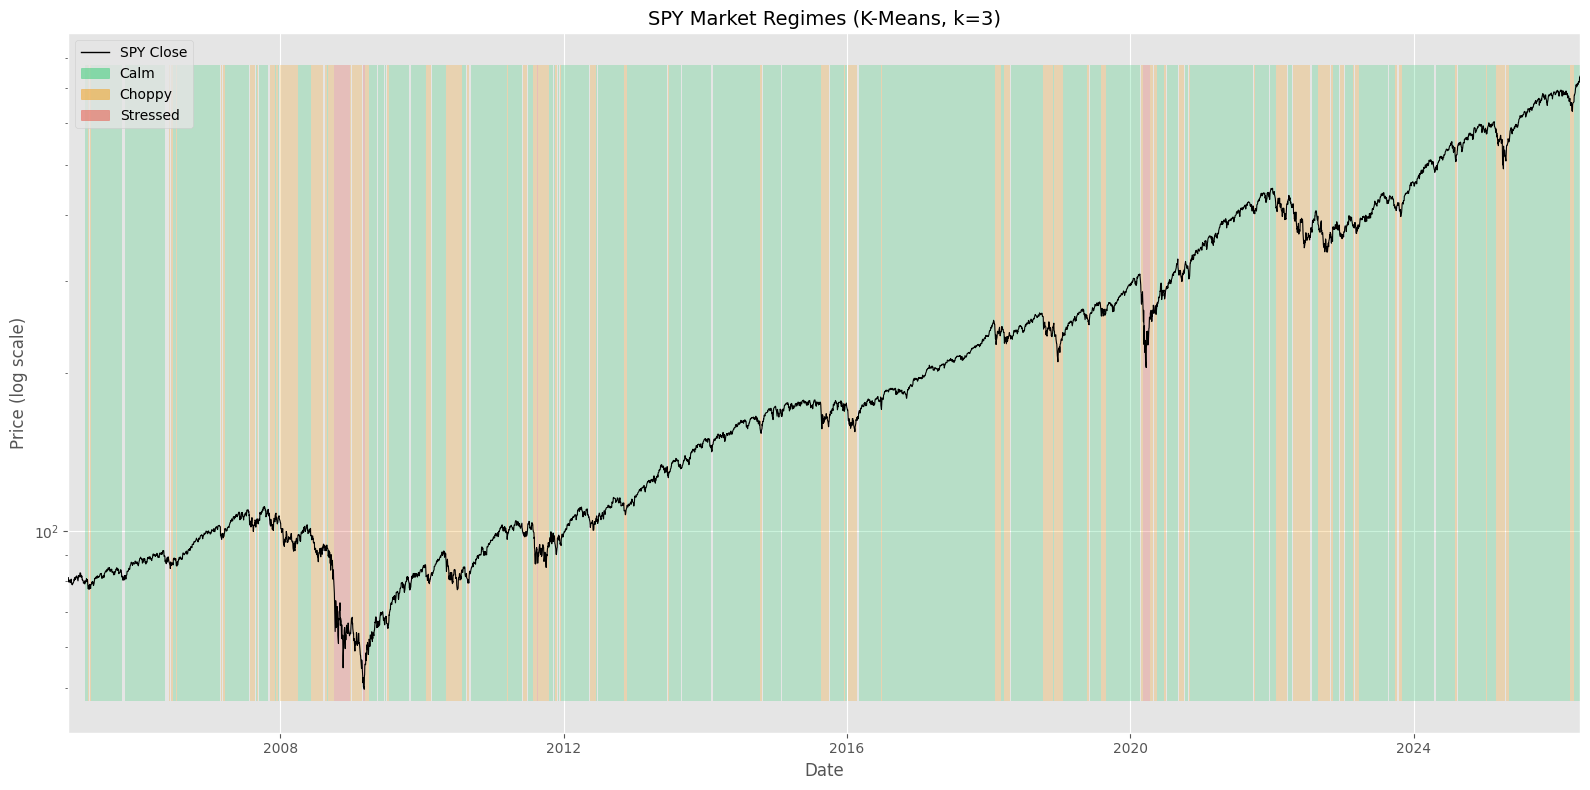

Chart saved to data/regime_timeline.png


In [11]:
REGIME_COLORS = {'Calm': '#2ecc71', 'Choppy': '#f39c12', 'Stressed': '#e74c3c'}

fig, ax = plt.subplots(figsize=(16, 8))

# Plot SPY price
ax.plot(df.index, df['Close'], color='black', linewidth=0.8, zorder=5, label='SPY Close')

# Shade background by regime
for regime, color in REGIME_COLORS.items():
    mask = df['Regime'] == regime
    ax.fill_between(
        df.index,
        df['Close'].min() * 0.95,
        df['Close'].max() * 1.05,
        where=mask,
        color=color,
        alpha=0.25,
        linewidth=0
    )

# Build legend manually
price_line = plt.Line2D([0], [0], color='black', linewidth=1, label='SPY Close')
patches = [mpatches.Patch(color=c, alpha=0.5, label=r) for r, c in REGIME_COLORS.items()]
ax.legend(handles=[price_line] + patches, loc='upper left', fontsize=10)

ax.set_title('SPY Market Regimes (K-Means, k=3)', fontsize=14)
ax.set_ylabel('Price (log scale)')
ax.set_xlabel('Date')
ax.set_yscale('log')
ax.set_xlim(df.index.min(), df.index.max())
plt.tight_layout()
plt.savefig('../data/regime_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/regime_timeline.png")


## 10. Event Dates Preview (CPI and FOMC)

We load the pre-compiled event dates from `events/event_dates.py` and preview them. These will be used in Phase 2 for event-window analysis.

**Sources:**
- CPI release dates: [BLS CPI release schedule](https://www.bls.gov/cpi/)
- FOMC decision dates: [Federal Reserve FOMC historical materials](https://www.federalreserve.gov/monetarypolicy/fomc_historical_year.htm)


In [12]:
import sys
sys.path.insert(0, '../events')
from event_dates import CPI_DATES, FOMC_DATES

cpi_series  = pd.to_datetime(CPI_DATES)
fomc_series = pd.to_datetime(FOMC_DATES)

print(f"CPI dates loaded:  {len(cpi_series)} entries ({cpi_series.min().date()} to {cpi_series.max().date()})")
print(f"FOMC dates loaded: {len(fomc_series)} entries ({fomc_series.min().date()} to {fomc_series.max().date()})")

# Preview as a combined table
events_df = pd.DataFrame({
    'event_type': ['CPI'] * len(cpi_series) + ['FOMC'] * len(fomc_series),
    'event_date': list(cpi_series) + list(fomc_series),
    'source': ['BLS'] * len(cpi_series) + ['Federal Reserve'] * len(fomc_series)
}).sort_values('event_date').reset_index(drop=True)

print()
print("Sample of event dates (first 10 rows):")
print(events_df.head(10).to_string(index=False))


CPI dates loaded:  180 entries (2010-01-15 to 2024-12-11)
FOMC dates loaded: 122 entries (2010-01-27 to 2024-12-18)

Sample of event dates (first 10 rows):
event_type event_date          source
       CPI 2010-01-15             BLS
      FOMC 2010-01-27 Federal Reserve
       CPI 2010-02-19             BLS
      FOMC 2010-03-16 Federal Reserve
       CPI 2010-03-18             BLS
       CPI 2010-04-14             BLS
      FOMC 2010-04-28 Federal Reserve
       CPI 2010-05-19             BLS
       CPI 2010-06-17             BLS
      FOMC 2010-06-23 Federal Reserve


---
## Summary

This notebook has completed the following Phase 1 steps:

1. Downloaded and cached SPY daily data from 2005 onwards.
2. Cleaned the data (removed duplicates and NaN rows).
3. Computed daily log returns, 20-day annualised realised volatility, 20-day momentum, and 60-day rolling drawdown.
4. Standardised features with `StandardScaler`.
5. Evaluated K-Means for k = 2, 3, 4, 5 using silhouette scores.
6. Fitted K-Means with k = 3 (`random_state=42`, `n_init=10`).
7. Labelled clusters as **Calm**, **Choppy**, and **Stressed** based on centroid volatility ordering.
8. Validated that 2008-2009, March 2020, and 2022 are predominantly Stressed or Choppy.
9. Produced a regime timeline chart saved to `data/regime_timeline.png`.
10. Loaded and previewed the CPI/FOMC event date dataset for Phase 2.

**Next step (Phase 2):** Event-window analysis — measure SPY returns in the days surrounding CPI and FOMC releases, stratified by regime.
